## **Random Forest Using scikit-learn**

### **Topic Roadmap**

**1. Create and visualize a non-linear dataset**

**2. Compare one tree with a random forest**

**3. Evaluate the forest**

**4. Inspect feature importance**

**5. Key revision notes**

## **1. Dataset and Split**

The original notebook used noisy concentric circles. The same dataset is retained with a fixed split for reproducibility.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
X, y = make_circles(n_samples=1000, factor=0.35, noise=0.12, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

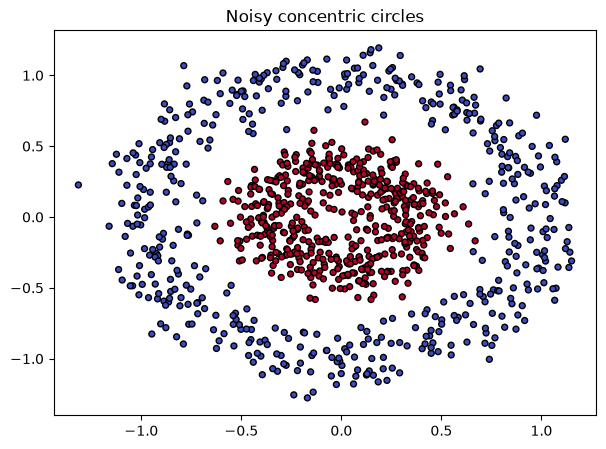

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=18)
plt.title("Noisy concentric circles")
plt.show()

## **2. Compare a Single Tree and a Random Forest**

The forest averages many randomized trees, which generally makes the decision boundary less sensitive to one sample.

In [3]:
single_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
random_forest = RandomForestClassifier(
    n_estimators=200, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1
)
for model in [single_tree, random_forest]:
    model.fit(X_train, y_train)
    print(type(model).__name__, f"accuracy = {model.score(X_test, y_test):.3f}")

DecisionTreeClassifier accuracy = 0.990
RandomForestClassifier accuracy = 0.995


## **3. Plot the Forest Boundary**

The grid prediction shows how the fitted forest separates the two classes.

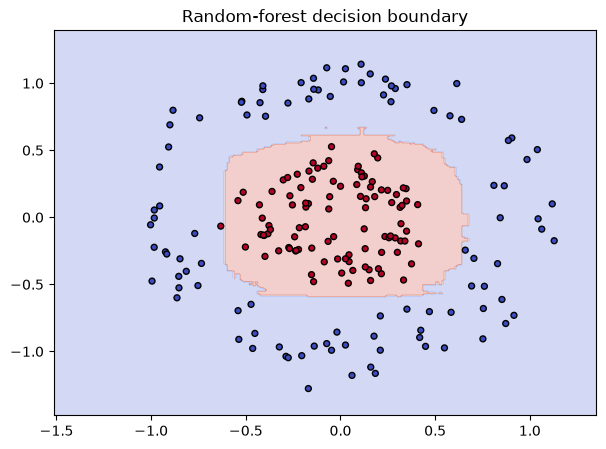

In [4]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - .2, X[:, 0].max() + .2, 250),
                     np.linspace(X[:, 1].min() - .2, X[:, 1].max() + .2, 250))
grid_predictions = random_forest.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, grid_predictions, alpha=0.25, cmap="coolwarm")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", edgecolor="black", s=18)
plt.title("Random-forest decision boundary")
plt.show()

### **Key Revision Notes**

- `RandomForestClassifier` is a bagged collection of randomized decision trees.
- `max_features="sqrt"` is a common classification default.
- More trees usually stabilize predictions, but they increase training and inference cost.
- Random forests can model non-linear interactions without feature scaling.